<a href="https://colab.research.google.com/github/gillicik/Veri-Analizi-Okulu_HSB-Modulu_Python_2025-2026/blob/main/Python_ile_Do%C4%9Fal_Dil_%C4%B0%C5%9Fleme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python ile Doğal Dil İşleme

### Bölüm 1 — Metin Ön İşleme (40 dk)

#### Kullanılacak kütüphaneler ve görevleri

- **re** — Düzenli ifadeler ile metin temizleme (noktalama kaldırma, özel karakter temizleme vb.)

- **zeyrek** — Türkçe morfolojik analiz (Zemberek’in Python portu). Kelime kökü bulma ve ek analizi için kullanılır.

- **nltk** — Doğal dil işleme yardımcı araçları (stopword listeleri, tokenization vb.)

- **pandas** — Veri yönetimi ve veri çerçevesi (DataFrame) işlemleri

- **collections.Counter** — Kelime frekanslarının hızlı şekilde sayılması

- **wordcloud** — Kelime frekanslarını görsel olarak kelime bulutu şeklinde gösterme

- **matplotlib** — Grafik ve görselleştirme (bar chart, histogram vb.)

- **transformers** — Hugging Face modelleri ile:
  - duygu analizi (sentiment analysis)
  - NER (Named Entity Recognition)
  - metin sınıflandırma

- **datasets** — Hugging Face veri setlerini yükleme ve yönetme

- **torch (PyTorch)** — Derin öğrenme modellerinin çalışması için kullanılan temel framework (transformer modellerinin çoğu bunun üzerinde çalışır)

- **tqdm** — Uzun işlemlerde ilerleme çubuğu (progress bar) gösterir

- **scikit-learn** — Makine öğrenmesi araçları:
  - metin vektörleştirme (TF-IDF vb.)
  - model eğitimi
  - değerlendirme metrikleri (precision, recall, F1)

In [ ]:
%pip install zeyrek wordcloud matplotlib pandas nltk transformers datasets torch tqdm scikit-learn gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 931.0/931.0 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.5 MB/s eta 0:00:00


In [ ]:
# NLTK Türkçe stopword indirme
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

#### 1.1 Örnek Metin Tanımlama

In [ ]:
metin = """
İstanbul, Türkiye'nin en kalabalık şehridir. 2024 yılında nüfusu 16 milyonu aşmıştır.
Şehir, hem Avrupa hem de Asya kıtasında yer almaktadır! Tarihi yarımada, UNESCO
Dünya Mirası Listesi'ndedir... İstanbul'da yaşamak hem güzel hem de zordur.
Toplu taşıma ile ulaşım oldukça yaygındır; ancak trafik büyük bir sorundur.
@kullanici123 İstanbul'u çok seviyorum!!! #istanbul #türkiye
Daha fazla bilgi için: https://istanbul.gov.tr adresini ziyaret edin.
"""

print("Ham metin:")
print(metin)
print(f"\nKarakter sayısı: {len(metin)}")

Ham metin:

İstanbul, Türkiye'nin en kalabalık şehridir. 2024 yılında nüfusu 16 milyonu aşmıştır.
Şehir, hem Avrupa hem de Asya kıtasında yer almaktadır! Tarihi yarımada, UNESCO
Dünya Mirası Listesi'ndedir... İstanbul'da yaşamak hem güzel hem de zordur.
Toplu taşıma ile ulaşım oldukça yaygındır; ancak trafik büyük bir sorundur.
@kullanici123 İstanbul'u çok seviyorum!!! #istanbul #türkiye
Daha fazla bilgi için: https://istanbul.gov.tr adresini ziyaret edin.


Karakter sayısı: 450


#### 1.2 Küçük Harfe Çevirme

In [ ]:
metin_kucuk = metin.lower()
print(metin_kucuk)


i̇stanbul, türkiye'nin en kalabalık şehridir. 2024 yılında nüfusu 16 milyonu aşmıştır.
şehir, hem avrupa hem de asya kıtasında yer almaktadır! tarihi yarımada, unesco
dünya mirası listesi'ndedir... i̇stanbul'da yaşamak hem güzel hem de zordur.
toplu taşıma ile ulaşım oldukça yaygındır; ancak trafik büyük bir sorundur.
@kullanici123 i̇stanbul'u çok seviyorum!!! #istanbul #türkiye
daha fazla bilgi için: https://istanbul.gov.tr adresini ziyaret edin.



In [ ]:
# Türkçe'de büyük-küçük harf dönüşümü dikkat gerektirir
# Python'da "İ" -> "i" ve "I" -> "ı" dönüşümü sorunludur

metin_kucuk = metin.lower()
print(metin_kucuk)

# Sorun: "Isparta" -> "isparta" (noktalı) olabiliyor
# Pratik çözüm:
def turkce_kucuk_harf(metin):
    metin = metin.replace("İ", "i")
    metin = metin.replace("I", "ı")
    return metin.lower()

metin_kucuk = turkce_kucuk_harf(metin)
print(metin_kucuk)


i̇stanbul, türkiye'nin en kalabalık şehridir. 2024 yılında nüfusu 16 milyonu aşmıştır.
şehir, hem avrupa hem de asya kıtasında yer almaktadır! tarihi yarımada, unesco
dünya mirası listesi'ndedir... i̇stanbul'da yaşamak hem güzel hem de zordur.
toplu taşıma ile ulaşım oldukça yaygındır; ancak trafik büyük bir sorundur.
@kullanici123 i̇stanbul'u çok seviyorum!!! #istanbul #türkiye
daha fazla bilgi için: https://istanbul.gov.tr adresini ziyaret edin.


istanbul, türkiye'nin en kalabalık şehridir. 2024 yılında nüfusu 16 milyonu aşmıştır.
şehir, hem avrupa hem de asya kıtasında yer almaktadır! tarihi yarımada, unesco
dünya mirası listesi'ndedir... istanbul'da yaşamak hem güzel hem de zordur.
toplu taşıma ile ulaşım oldukça yaygındır; ancak trafik büyük bir sorundur.
@kullanici123 istanbul'u çok seviyorum!!! #istanbul #türkiye
daha fazla bilgi için: https://istanbul.gov.tr adresini ziyaret edin.



#### 1.3 Noktalama ve Özel Karakterlerin Temizlenmesi

In [ ]:
import re

def metin_temizle(metin):
    # URL'leri kaldır
    metin = re.sub(r'https?://\S+', '', metin)
    # Kullanıcı adlarını kaldır (@mentions)
    metin = re.sub(r'@\w+', '', metin)
    # Hashtag'leri kaldır
    metin = re.sub(r'#\w+', '', metin)
    # Sayıları kaldır
    metin = re.sub(r'\d+', '', metin)
    # Noktalama işaretlerini kaldır (Türkçe karakterleri koru)
    metin = re.sub(r'[^\wçğıöşüÇĞİÖŞÜ\s]', '', metin)
    # Fazla boşlukları temizle
    metin = re.sub(r'\s+', ' ', metin).strip()
    return metin

temiz_metin = metin_temizle(metin_kucuk)
print("Temizlenmiş metin:")
print(temiz_metin)

Temizlenmiş metin:
istanbul türkiyenin en kalabalık şehridir yılında nüfusu milyonu aşmıştır şehir hem avrupa hem de asya kıtasında yer almaktadır tarihi yarımada unesco dünya mirası listesindedir istanbulda yaşamak hem güzel hem de zordur toplu taşıma ile ulaşım oldukça yaygındır ancak trafik büyük bir sorundur istanbulu çok seviyorum daha fazla bilgi için adresini ziyaret edin


#### 1.4 Tokenization — Metni Kelimelere Ayırma

In [ ]:
# Basit yöntem: split()
kelimeler = temiz_metin.split()
print(f"Kelime sayısı: {len(kelimeler)}")
print(f"İlk 10 kelime: {kelimeler[:10]}")

# NLTK ile tokenization
from nltk.tokenize import word_tokenize
kelimeler_nltk = word_tokenize(temiz_metin, language='turkish')
print(f"\nNLTK ile kelime sayısı: {len(kelimeler_nltk)}")
print(f"İlk 10 kelime: {kelimeler_nltk[:10]}")

Kelime sayısı: 52
İlk 10 kelime: ['istanbul', 'türkiyenin', 'en', 'kalabalık', 'şehridir', 'yılında', 'nüfusu', 'milyonu', 'aşmıştır', 'şehir']

NLTK ile kelime sayısı: 52
İlk 10 kelime: ['istanbul', 'türkiyenin', 'en', 'kalabalık', 'şehridir', 'yılında', 'nüfusu', 'milyonu', 'aşmıştır', 'şehir']


#### 1.5 Stopword (Etkisiz Kelime) Çıkarma

In [ ]:
from nltk.corpus import stopwords

# Türkçe stopword listesi
turkce_stopwords = set(stopwords.words('turkish'))
print(f"Stopword sayısı: {len(turkce_stopwords)}")
print(f"Örnekler: {list(turkce_stopwords)[:20]}")

# Stopword'leri çıkar
filtreli_kelimeler = [k for k in kelimeler if k not in turkce_stopwords]
print(f"\nÖnce: {len(kelimeler)} kelime")
print(f"Sonra: {len(filtreli_kelimeler)} kelime")
print(f"Kalan kelimeler: {filtreli_kelimeler}")

Stopword sayısı: 53
Örnekler: ['ama', 'birşey', 'ne', 'mı', 'çok', 'nerde', 'acaba', 'biz', 'niye', 'hiç', 'hem', 'ya', 'şey', 'en', 'aslında', 'bazı', 'siz', 'az', 'mü', 'her']

Önce: 52 kelime
Sonra: 41 kelime
Kalan kelimeler: ['istanbul', 'türkiyenin', 'kalabalık', 'şehridir', 'yılında', 'nüfusu', 'milyonu', 'aşmıştır', 'şehir', 'avrupa', 'asya', 'kıtasında', 'yer', 'almaktadır', 'tarihi', 'yarımada', 'unesco', 'dünya', 'mirası', 'listesindedir', 'istanbulda', 'yaşamak', 'güzel', 'zordur', 'toplu', 'taşıma', 'ulaşım', 'oldukça', 'yaygındır', 'ancak', 'trafik', 'büyük', 'bir', 'sorundur', 'istanbulu', 'seviyorum', 'fazla', 'bilgi', 'adresini', 'ziyaret', 'edin']


#### 1.6 Kök/Gövde Bulma — Zeyrek ile Morfolojik Analiz

In [ ]:
import zeyrek

analyzer = zeyrek.MorphAnalyzer()

# Tek kelime analizi
ornek_kelimeler = ["İstanbul'da", "yaşamak", "seviyorum", "güzeldir", "gidiyormuş"]

for kelime in ornek_kelimeler:
    sonuclar = analyzer.lemmatize(kelime)
    print(f"{kelime:20s} -> {sonuclar}")

# Cümle üzerinde lemmatization
def koklerini_bul(metin):
    kelimeler = metin.split()
    kokler = []
    for kelime in kelimeler:
        sonuc = analyzer.lemmatize(kelime)
        if sonuc:
            kok = sonuc[0][1][0]  # İlk analiz sonucunun kökü
            kokler.append(kok)
        else:
            kokler.append(kelime)
    return kokler

kokler = koklerini_bul(temiz_metin)
print("\nKökler:")
print(kokler)

İstanbul'da          -> [('İstanbulda', ['İstanbul'])]
yaşamak              -> [('yaşamak', ['yaşamak'])]
seviyorum            -> [('seviyorum', ['sevmek'])]
güzeldir             -> [('güzeldir', ['güzel'])]
gidiyormuş           -> [('gidiyormuş', ['gitmek'])]

Kökler:
['İstanbul', 'Türkiye', 'en', 'kalaba', 'şehir', 'yıl', 'nüfus', 'milyon', 'aşmak', 'şehir', 'hem', 'Avrupa', 'hem', 'de', 'Asya', 'kıta', 'yermek', 'almak', 'tarihî', 'yarımada', 'Unesco', 'Dünya', 'mira', 'liste', 'İstanbul', 'yaşamak', 'hem', 'güzel', 'hem', 'de', 'zor', 'toplu', 'taşım', 'ilmek', 'ulaşım', 'oldukça', 'yaygı', 'ancak', 'trafik', 'Büyük', 'bir', 'soru', 'İstanbul', 'çok', 'sevmek', 'daha', 'fazla', 'bilgi', 'içmek', 'adres', 'ziyaret', 'etmek']


#### 1.7 Hepsini Birleştiren Pipeline Fonksiyonu

In [ ]:
def nlp_pipeline(metin):
    """Türkçe metin ön işleme pipeline'ı"""
    # 1. Küçük harf
    metin = turkce_kucuk_harf(metin)
    # 2. Temizleme
    metin = metin_temizle(metin)
    # 3. Tokenization
    kelimeler = metin.split()
    # 4. Stopword çıkarma
    kelimeler = [k for k in kelimeler if k not in turkce_stopwords]
    # 5. Kök bulma
    kokler = koklerini_bul(' '.join(kelimeler))
    return kokler

# Test
sonuc = nlp_pipeline(metin)
print("Pipeline sonucu:")
print(sonuc)

Pipeline sonucu:
['İstanbul', 'Türkiye', 'kalaba', 'şehir', 'yıl', 'nüfus', 'milyon', 'aşmak', 'şehir', 'Avrupa', 'Asya', 'kıta', 'yermek', 'almak', 'tarihî', 'yarımada', 'Unesco', 'Dünya', 'mira', 'liste', 'İstanbul', 'yaşamak', 'güzel', 'zor', 'toplu', 'taşım', 'ulaşım', 'oldukça', 'yaygı', 'ancak', 'trafik', 'Büyük', 'bir', 'soru', 'İstanbul', 'sevmek', 'fazla', 'bilgi', 'adres', 'ziyaret', 'etmek']


### Bölüm 2 — Kelime Frekansı & Kelime Bulutu

#### 2.1 Daha Büyük Bir Veri Seti ile Çalışma

In [ ]:
# Birden fazla Türkçe metin
metinler = [
    "Türk mutfağı dünyaca ünlüdür. Kebap, baklava ve lahmacun en bilinen yemeklerdir.",
    "İstanbul Boğazı, Asya ile Avrupa'yı birbirine bağlayan doğal bir su yoludur.",
    "Türkiye'de çay kültürü çok önemlidir. Çay, günlük hayatın vazgeçilmez bir parçasıdır.",
    "Kapadokya'nın peri bacaları her yıl milyonlarca turisti cezbetmektedir.",
    "Türk edebiyatı, Orhan Pamuk'un Nobel ödülüyle dünya sahnesinde yer edinmiştir.",
    "Ege kıyılarındaki antik kentler, tarihi zenginliğin en güzel örnekleridir.",
    "Türk kahvesi, UNESCO somut olmayan kültürel miras listesindedir.",
    "Antalya, turizm sektörünün en önemli merkezlerinden biridir.",
    "Pamukkale travertenleri, doğanın eşsiz bir armağanıdır.",
    "Efes antik kenti, dünyanın en iyi korunmuş antik kentlerinden biridir.",
    "Türk hamamı geleneği yüzyıllardır sürmektedir.",
    "Mevlana'nın felsefesi dünya genelinde ilgi görmektedir.",
    "Trabzon'un yaylalarında doğa yürüyüşleri çok popülerdir.",
    "Gaziantep mutfağı, UNESCO gastronomi şehri unvanına sahiptir.",
    "Mardin'in taş evleri, Mezopotamya'nın kültürel mirasını yansıtır.",
]

# Pipeline'ı tüm metinlere uygula
tum_kelimeler = []
for m in metinler:
    tum_kelimeler.extend(nlp_pipeline(m))

print(f"Toplam kelime (işlenmiş): {len(tum_kelimeler)}")

Toplam kelime (işlenmiş): 113


In [ ]:
tum_kelimeler[:10]

['Türk',
 'mutfak',
 'Dünya',
 'ün',
 'kebap',
 'baklava',
 'lahmacun',
 'bilmek',
 'yemek',
 'İstanbul']

#### 2.2 Kelime Frekans Analizi

In [ ]:
from collections import Counter

# En sık geçen kelimeler
frekans = Counter(tum_kelimeler)
en_sik_20 = frekans.most_common(20)

print("En sık geçen 20 kelime:")
print("-" * 30)
for kelime, sayi in en_sik_20:
    print(f"{kelime:20s} : {sayi}")

En sık geçen 20 kelime:
------------------------------
Türk                 : 4
Dünya                : 4
bir                  : 3
antik                : 3
kent                 : 3
mutfak               : 2
Çay                  : 2
önem                 : 2
Unesco               : 2
kültürel             : 2
biri                 : 2
ün                   : 1
kebap                : 1
baklava              : 1
lahmacun             : 1
bilmek               : 1
yemek                : 1
İstanbul             : 1
boğaz                : 1
Asya                 : 1


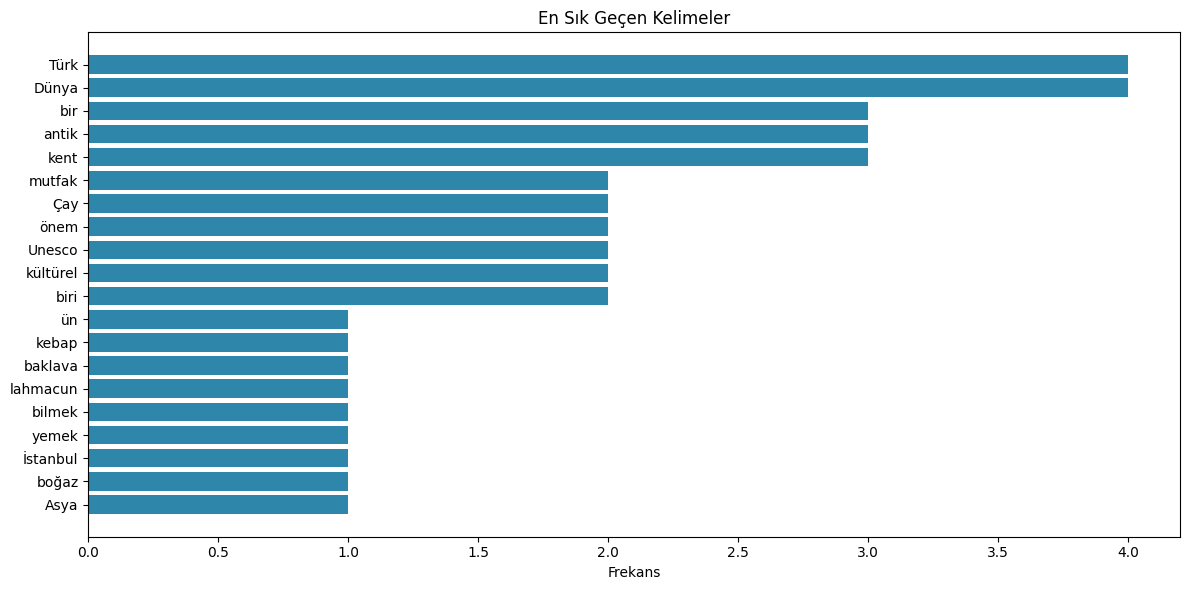

In [ ]:
# Frekans grafiği
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
kelimeler_grafik = [k for k, _ in en_sik_20]
sayilar = [s for _, s in en_sik_20]

plt.barh(kelimeler_grafik[::-1], sayilar[::-1], color='#2E86AB')
plt.xlabel('Frekans')
plt.title('En Sık Geçen Kelimeler')
plt.tight_layout()
plt.show()

#### 2.3 Kelime Bulutu Oluşturma

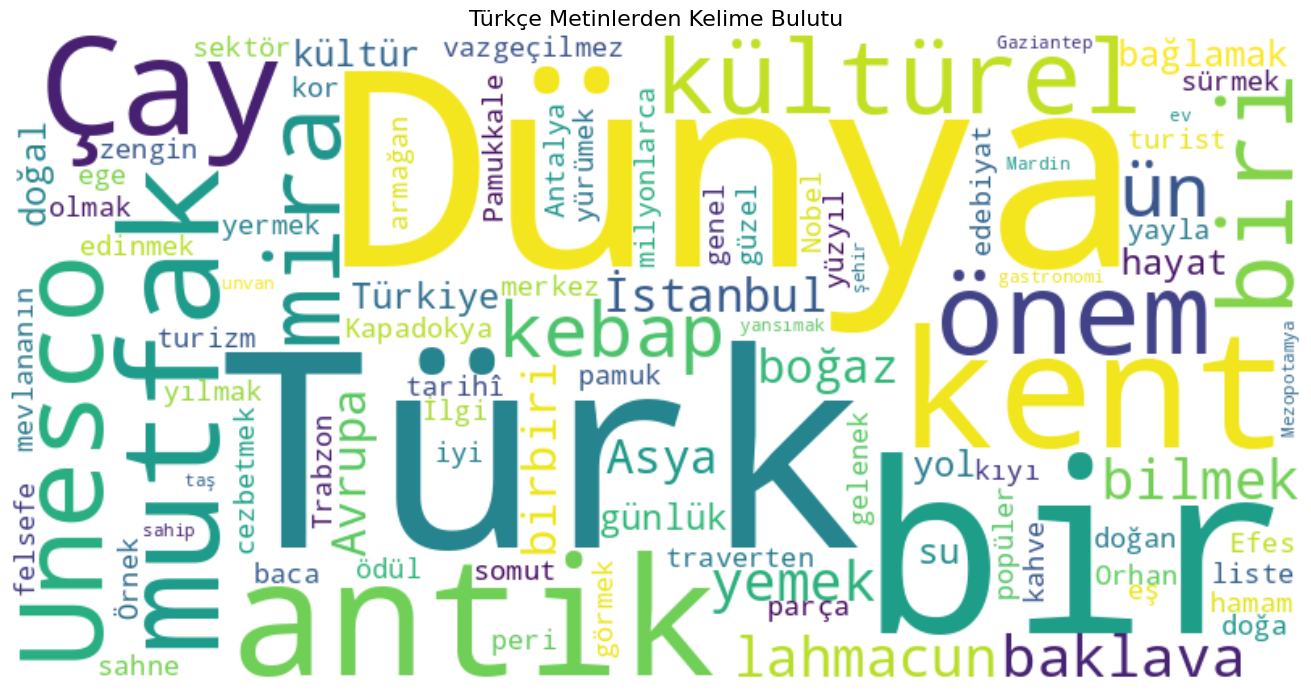

In [ ]:
from wordcloud import WordCloud

# Kelimeleri birleştir
metin_birlesmis = ' '.join(tum_kelimeler)

# Kelime bulutu
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='viridis',
    font_path=None,  # Sisteme göre Türkçe font yolu verilebilir
    collocations=False
).generate(metin_birlesmis)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Türkçe Metinlerden Kelime Bulutu', fontsize=16)
plt.tight_layout()
plt.show()

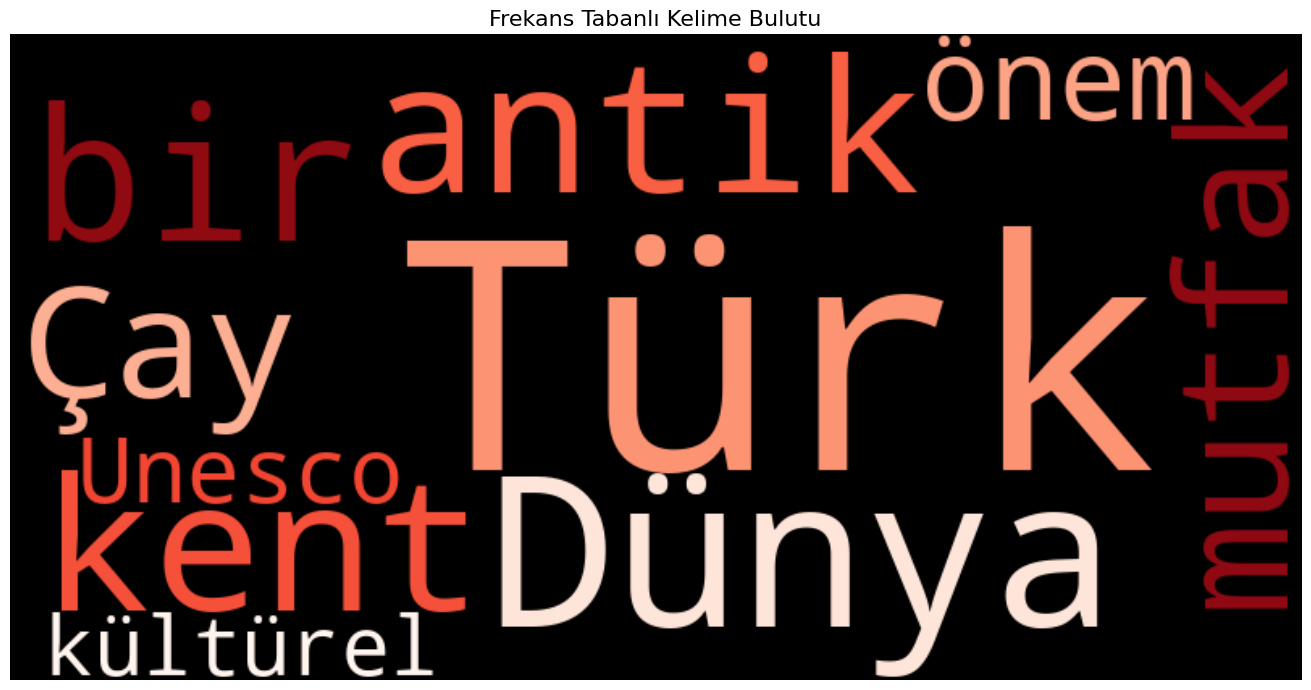

In [ ]:
# Farklı şekilde kelime bulutu — frekans sözlüğünden
wordcloud_frekans = WordCloud(
    width=800,
    height=400,
    background_color='black',
    max_words=10,
    colormap='Reds',
    collocations=False
).generate_from_frequencies(frekans)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_frekans, interpolation='bilinear')
plt.axis('off')
plt.title('Frekans Tabanlı Kelime Bulutu', fontsize=16)
plt.tight_layout()
plt.show()

#### 2.4 Dosyadan Elde Edilen Veriyi İşleme

In [ ]:
dosya_adi = 'istanbul_tarihi.txt'

with open(dosya_adi, 'r', encoding='utf-8') as f:
    metin_dosyadan = f.read()
print(f"'{dosya_adi}' dosyasından okunan metin:")
print(metin_dosyadan[:200] + ('...' if len(metin_dosyadan) > 200 else '')) # İlk 200 karakteri göster

'istanbul_tarihi.txt' dosyasından okunan metin:
İstanbul’un Tarihi: Kısa Bir Anlatı

İstanbul, dünya tarihinin en önemli şehirlerinden biridir. Avrupa ile
Asya’nın kesiştiği noktada yer alan bu şehir, binlerce yıl boyunca
farklı medeniyetlere ev sa...


In [ ]:
# NLP pipeline'ını uygula
islenmis_kelimeler_dosyadan = nlp_pipeline(metin_dosyadan)
print(f"\nİşlenmiş kelime sayısı: {len(islenmis_kelimeler_dosyadan)}")


İşlenmiş kelime sayısı: 374


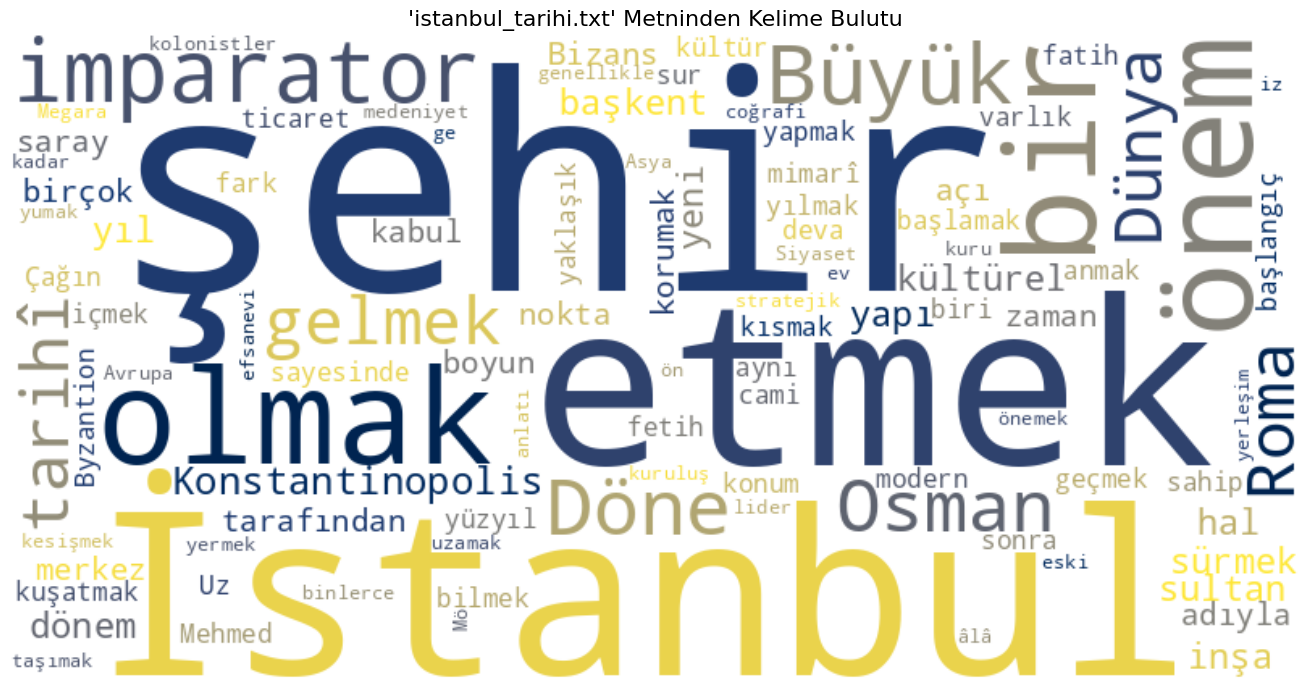

In [ ]:
# Kelimeleri birleştirerek kelime bulutu oluştur
metin_birlesmis_dosyadan = ' '.join(islenmis_kelimeler_dosyadan)

wordcloud_dosyadan = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='cividis',
    font_path=None,
    collocations=False
).generate(metin_birlesmis_dosyadan)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_dosyadan, interpolation='bilinear')
plt.axis('off')
plt.title(f"'{dosya_adi}' Metninden Kelime Bulutu", fontsize=16)
plt.tight_layout()
plt.show()

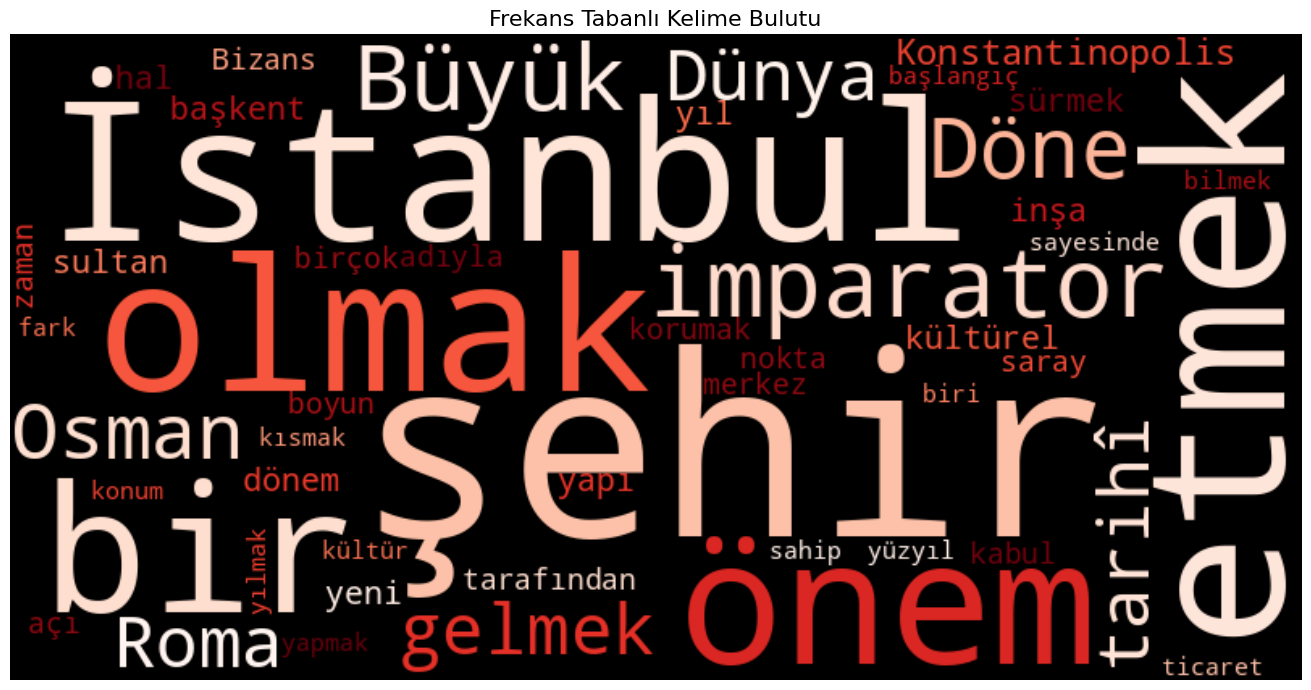

In [ ]:
frekans = Counter(islenmis_kelimeler_dosyadan)

wordcloud_frekans = WordCloud(
    width=800,
    height=400,
    background_color='black',
    max_words=50,
    colormap='Reds',
    collocations=False
).generate_from_frequencies(frekans)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_frekans, interpolation='bilinear')
plt.axis('off')
plt.title('Frekans Tabanlı Kelime Bulutu', fontsize=16)
plt.tight_layout()
plt.show()

### Bölüm 3 — Duygu Analizi

#### 3.1 Hugging Face ile Türkçe Duygu Analizi

In [ ]:
from transformers import pipeline
import tqdm as notebook_tqdm
import torch

# Türkçe duygu analizi modeli
# https://huggingface.co/savasy/bert-base-turkish-sentiment-cased

duygu_analizi = pipeline(
    "sentiment-analysis",
    model="savasy/bert-base-turkish-sentiment-cased"
)

# Tek cümle analizi
ornek_cumleler = [
    "Bu filmi beğendim ama diş ağrım nedeniyle odaklanamadım.",
    "Hava bugün çok kötü, hiç dışarı çıkasım yok.",
    "Yemek fena değildi ama beklediğim kadar iyi de değildi.",
    "Türkiye'nin doğal güzellikleri muhteşem.",
    "Trafik berbat, sinirlerim bozuldu.",
    "Kitabı okuyunca çok etkilendim, herkese tavsiye ederim.",
    "Müşteri hizmetleri çok ilgisiz, bir daha gelmem.",
    "Bugün güzel bir gün, her şey yolunda gidiyor.",
]

print("Duygu Analizi Sonuçları")
print("=" * 60)
for cumle in ornek_cumleler:
    sonuc = duygu_analizi(cumle)[0]
    etiket = sonuc['label']
    skor = sonuc['score']
    emoji = "😊" if etiket == "positive" else "😞" if etiket == "negative" else "😐"
    print(f"{emoji} [{etiket:8s}] (güven: {skor:.2f}) | {cumle}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Duygu Analizi Sonuçları
😊 [positive] (güven: 0.79) | Bu filmi beğendim ama diş ağrım nedeniyle odaklanamadım.
😞 [negative] (güven: 0.99) | Hava bugün çok kötü, hiç dışarı çıkasım yok.
😞 [negative] (güven: 1.00) | Yemek fena değildi ama beklediğim kadar iyi de değildi.
😊 [positive] (güven: 0.97) | Türkiye'nin doğal güzellikleri muhteşem.
😞 [negative] (güven: 1.00) | Trafik berbat, sinirlerim bozuldu.
😊 [positive] (güven: 0.97) | Kitabı okuyunca çok etkilendim, herkese tavsiye ederim.
😞 [negative] (güven: 1.00) | Müşteri hizmetleri çok ilgisiz, bir daha gelmem.
😊 [positive] (güven: 0.97) | Bugün güzel bir gün, her şey yolunda gidiyor.


#### 3.2 Toplu Duygu Analizi ve Görselleştirme

In [ ]:
import pandas as pd

# Daha fazla metin ile analiz
yorumlar = [
    "Ürün kalitesi çok iyi, memnun kaldım.",
    "Kargo çok geç geldi, çok kötü bir deneyimdi.",
    "Fiyat-performans açısından gayet makul.",
    "Ambalaj hasarlı geldi, ürün de çizilmiş.",
    "Müthiş bir ürün, tekrar alırım kesinlikle.",
    "İade sürecinde çok zorlandım, destek yetersiz.",
    "Beklediğimden çok daha kaliteli çıktı.",
    "Rengi fotoğraftakinden çok farklı, hayal kırıklığı.",
    "Hızlı kargo ve güzel paketleme için teşekkürler.",
    "Bu paraya bu kalite olmaz, paramı çöpe attım.",
    "Gayet güzel, tavsiye ederim.",
    "Bir daha bu mağazadan alışveriş yapmam.",
]

# Toplu analiz
sonuclar = []
for yorum in yorumlar:
    analiz = duygu_analizi(yorum)[0]
    sonuclar.append({
        'yorum': yorum,
        'duygu': analiz['label'],
        'guven': round(analiz['score'], 3)
    })

df = pd.DataFrame(sonuclar)
print(df.to_string(index=False))

# Duygu dağılımı
print("\n\nDuygu Dağılımı:")
print(df['duygu'].value_counts())

                                              yorum    duygu  guven
              Ürün kalitesi çok iyi, memnun kaldım. positive  0.594
       Kargo çok geç geldi, çok kötü bir deneyimdi. negative  0.999
            Fiyat-performans açısından gayet makul. negative  0.881
           Ambalaj hasarlı geldi, ürün de çizilmiş. negative  0.999
         Müthiş bir ürün, tekrar alırım kesinlikle. positive  0.995
     İade sürecinde çok zorlandım, destek yetersiz. negative  0.999
             Beklediğimden çok daha kaliteli çıktı. negative  0.911
Rengi fotoğraftakinden çok farklı, hayal kırıklığı. negative  1.000
   Hızlı kargo ve güzel paketleme için teşekkürler. positive  0.975
      Bu paraya bu kalite olmaz, paramı çöpe attım. negative  0.998
                       Gayet güzel, tavsiye ederim. positive  0.689
            Bir daha bu mağazadan alışveriş yapmam. negative  0.689


Duygu Dağılımı:
duygu
negative    8
positive    4
Name: count, dtype: int64


In [ ]:
df.head()

,yorum,duygu,guven
0,"Ürün kalitesi çok iyi, memnun kaldım.",positive,0.594
1,"Kargo çok geç geldi, çok kötü bir deneyimdi.",negative,0.999
2,Fiyat-performans açısından gayet makul.,negative,0.881
3,"Ambalaj hasarlı geldi, ürün de çizilmiş.",negative,0.999
4,"Müthiş bir ürün, tekrar alırım kesinlikle.",positive,0.995


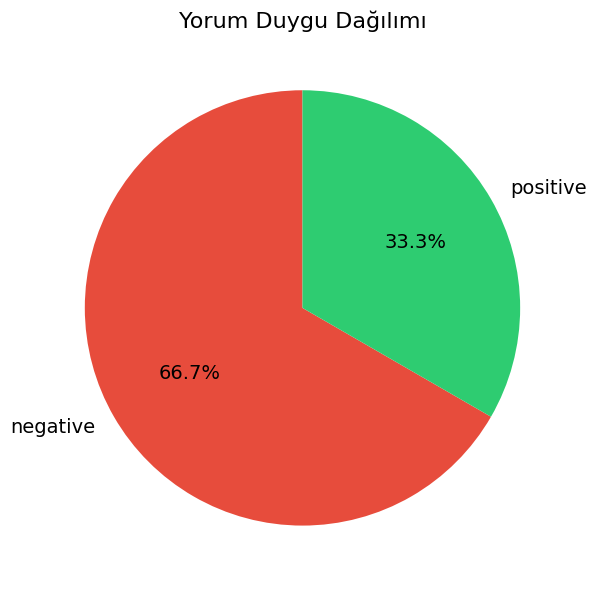

In [ ]:
# Pasta grafiği
duygu_sayilari = df['duygu'].value_counts()
renkler = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#95a5a6'}

plt.figure(figsize=(8, 6))
plt.pie(
    duygu_sayilari.values,
    labels=duygu_sayilari.index,
    colors=[renkler.get(d, '#777') for d in duygu_sayilari.index],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 14}
)
plt.title('Yorum Duygu Dağılımı', fontsize=16)
plt.tight_layout()
plt.show()

### Bölüm 4 — Adlandırılmış Varlık Tanıma / NER

#### 4.1 Hugging Face ile Türkçe NER

In [ ]:
from transformers import pipeline

# Türkçe NER modeli
# https://huggingface.co/savasy/bert-base-turkish-ner-cased
ner = pipeline(
    "ner",
    model="savasy/bert-base-turkish-ner-cased",
    aggregation_strategy="simple"
)

# Örnek metin
ornek_metin = """
Geçen hafta San Francisco’da düzenlenen teknoloji konferansında,
yapay zekâ ve veri analitiği alanında faaliyet gösteren Noventra
Labs şirketinin CEO’su Daniel Carter, şirketin yeni geliştirdiği
veri işleme platformunu tanıttı. Carter konuşmasında, platformun
özellikle büyük veri kümeleriyle çalışan araştırmacılar ve şirketler
için daha hızlı analiz imkânı sağlayacağını belirtti. Tanıtım
sırasında yapılan demoda, sistemin milyonlarca satırlık veriyi
kısa sürede işleyerek görselleştirebildiği gösterildi.

Etkinliğe ayrıca HelixData şirketinin kurucu ortağı Sophia Nguyen
ve BlueRiver Analytics’in teknoloji direktörü Mark Alvarez de katıldı.
Nguyen, Seattle’da yürüttükleri veri altyapısı projelerinden bahsederken,
Alvarez ise Austin’de kurulan yeni araştırma merkezleri hakkında bilgi
verdi. Konferansta ayrıca QuantumEdge Systems ve Atlas Compute gibi
şirketlerin temsilcileri de yer aldı.

Noventra Labs yetkilileri, şirketin önümüzdeki yıl Londra, Berlin ve
Singapur’da yeni ofisler açmayı planladığını açıkladı. Carter ayrıca
Stanford Üniversitesi ve Massachusetts Institute of Technology araştırma
ekipleriyle ortak çalışmalar yürüttüklerini ve bu iş birliklerinin
veri bilimi alanında yeni uygulamaların geliştirilmesine katkı
sağlayacağını ifade etti.
"""

sonuclar = ner(ornek_metin)

print("Adlandırılmış Varlık Tanıma Sonuçları")
print("=" * 50)
for s in sonuclar:
    print(f"  [{s['entity_group']:12s}]  {s['word']:30s}  (güven: {s['score']:.2f})")

config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: savasy/bert-base-turkish-ner-cased
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/40.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Adlandırılmış Varlık Tanıma Sonuçları
  [LOC         ]  San Francisco                   (güven: 0.99)
  [ORG         ]  Noventra Labs                   (güven: 0.98)
  [PER         ]  Daniel Car                      (güven: 0.98)
  [ORG         ]  HelixData                       (güven: 0.89)
  [PER         ]  Sophia Nguyen                   (güven: 0.99)
  [ORG         ]  BlueRiver Analytics             (güven: 0.95)
  [PER         ]  Mark Alvarez                    (güven: 0.99)
  [PER         ]  ##guyen                         (güven: 0.79)
  [LOC         ]  Seattle                         (güven: 0.97)
  [PER         ]  ##varez                         (güven: 0.75)
  [LOC         ]  Austin                          (güven: 0.98)
  [ORG         ]  QuantumEdge Systems             (güven: 0.98)
  [ORG         ]  Atlas Compute                   (güven: 0.99)
  [ORG         ]  Noventra Labs                   (güven: 0.94)
  [LOC         ]  Londra                          (güven: 1.00)
  

In [ ]:
sonuclar = ner(metin_dosyadan)

print("Adlandırılmış Varlık Tanıma Sonuçları")
print("=" * 50)
for s in sonuclar:
    print(f"  [{s['entity_group']:12s}]  {s['word']:30s}  (güven: {s['score']:.2f})")

Adlandırılmış Varlık Tanıma Sonuçları
  [LOC         ]  İstanbul                        (güven: 0.76)
  [LOC         ]  İstanbul                        (güven: 1.00)
  [LOC         ]  Avrupa                          (güven: 0.99)
  [LOC         ]  Asya                            (güven: 0.99)
  [LOC         ]  Bizans                          (güven: 0.48)
  [LOC         ]  İstanbul                        (güven: 0.98)
  [LOC         ]  Megara                          (güven: 0.98)
  [LOC         ]  ##tion                          (güven: 0.76)
  [PER         ]  Byzas                           (güven: 0.97)
  [LOC         ]  ##tion                          (güven: 0.46)
  [LOC         ]  Boğaziçi                        (güven: 0.96)
  [LOC         ]  Roma Dönemi                     (güven: 0.79)
  [LOC         ]  Roma İmparatorluğu              (güven: 0.98)
  [PER         ]  I. Konstantin                   (güven: 0.95)
  [LOC         ]  Roma İmparatorluğu              (güven: 0.98)
  

#### 4.2 Birden Fazla Metin Üzerinde NER

In [ ]:
haberler = [
    "Galatasaray, Şampiyonlar Ligi'nde Bayern Münih ile karşılaşacak.",
    "Orhan Pamuk, yeni romanını Frankfurt Kitap Fuarı'nda tanıttıp Berlin'e doğru yola çıktı.",
    "TBMM'de yeni eğitim yasası görüşüldü.",
    "Antalya Havalimanı'ndan bu yıl 35 milyon yolcu geçti.",
    "Boğaziçi Üniversitesi, yapay zekâ alanında yeni bir araştırma merkezi kurdu.",
]

print("Haberlerden Varlık Çıkarma")
print("=" * 60)

for i, haber in enumerate(haberler, 1):
    print(f"\nHaber {i}: {haber}")
    varliklar = ner(haber)
    if varliklar:
        for v in varliklar:
            print(f"   -> [{v['entity_group']:10s}] {v['word']}")
    else:
        print("   -> Varlık bulunamadı")

Haberlerden Varlık Çıkarma

Haber 1: Galatasaray, Şampiyonlar Ligi'nde Bayern Münih ile karşılaşacak.
   -> [ORG       ] Galatasaray
   -> [ORG       ] Şampiyonlar Ligi
   -> [ORG       ] Bayern Münih

Haber 2: Orhan Pamuk, yeni romanını Frankfurt Kitap Fuarı'nda tanıttıp Berlin'e doğru yola çıktı.
   -> [PER       ] Orhan Pamuk
   -> [ORG       ] Frankfurt Kitap Fuarı
   -> [LOC       ] Berlin

Haber 3: TBMM'de yeni eğitim yasası görüşüldü.
   -> [ORG       ] TBMM

Haber 4: Antalya Havalimanı'ndan bu yıl 35 milyon yolcu geçti.
   -> [ORG       ] Antalya Havalimanı

Haber 5: Boğaziçi Üniversitesi, yapay zekâ alanında yeni bir araştırma merkezi kurdu.
   -> [ORG       ] Boğaziçi Üniversitesi


In [ ]:
# Varlık türlerine göre gruplama
from collections import defaultdict

tum_varliklar = defaultdict(list)
for haber in haberler:
    sonuclar = ner(haber)
    for s in sonuclar:
        tum_varliklar[s['entity_group']].append(s['word'])

print("\nVarlık Türlerine Göre Gruplar:")
print("-" * 40)
for tur, isimler in tum_varliklar.items():
    benzersiz = list(set(isimler))
    print(f"\n{tur}:")
    for isim in benzersiz:
        print(f"   • {isim}")


Varlık Türlerine Göre Gruplar:
----------------------------------------

ORG:
   • TBMM
   • Galatasaray
   • Bayern Münih
   • Antalya Havalimanı
   • Şampiyonlar Ligi
   • Frankfurt Kitap Fuarı
   • Boğaziçi Üniversitesi

PER:
   • Orhan Pamuk

LOC:
   • Berlin


### Bölüm 5 — Film Türü Tahmini (Model Eğitimi)


#### 5.1 Veriyi Yükleme ve Hazırlama


In [ ]:
# https://www.kaggle.com/datasets/mechatronixs/tmdb-movies-dataset-20212025

import pandas as pd

df_movies = pd.read_csv('movies.csv')
print(f'Toplam satır: {len(df_movies):,}')
print('Sütunlar:', list(df_movies.columns))

# Gerekli alanları seç
df_model = df_movies[['overview', 'genres']].copy()
df_model = df_model.dropna(subset=['overview', 'genres'])

# Çoklu tür bilgisinden ilk türü hedef olarak al
df_model['genre_main'] = df_model['genres'].astype(str).str.split('|').str[0].str.strip()
df_model = df_model[df_model['overview'].str.len() > 20]

print(f'Temizlik sonrasında satır: {len(df_model):,}')
print('İlk 10 sütun dağılımı:')
print(df_model['genre_main'].value_counts().head(10))
df_model.head(3)


Toplam satır: 232,586
Sütunlar: ['tmdb_id', 'title', 'genres', 'popularity', 'overview']
Temizlik sonrasında satır: 156,706
İlk 10 sütun dağılımı:
genre_main
Documentary        40921
Drama              39441
Comedy             18541
Horror             13231
Animation          11125
Thriller            5848
Music               4775
Action              4387
Romance             4007
Science Fiction     2845
Name: count, dtype: int64


,overview,genres,genre_main
0,A young couple is pushed to the limits of sani...,Horror|Thriller,Horror
1,Jen and a group of friends set out to hike the...,Horror|Thriller,Horror
2,"Deputy Sheriff Joe ""Deke"" Deacon joins forces ...",Drama|Crime|Thriller,Drama


In [ ]:
df_movies.head()

,tmdb_id,title,genres,popularity,overview
0,776797,The Sadness,Horror|Thriller,6.6556,A young couple is pushed to the limits of sani...
1,630586,Wrong Turn,Horror|Thriller,5.3228,Jen and a group of friends set out to hike the...
2,602269,The Little Things,Drama|Crime|Thriller,4.7223,"Deputy Sheriff Joe ""Deke"" Deacon joins forces ..."
3,581734,Nomadland,Drama,4.3909,A woman in her sixties embarks on a journey th...
4,634528,The Marksman,Action|Drama|Thriller,5.0019,Jim Hanson’s quiet life is suddenly disturbed ...


#### 5.2 Eğitim/Test Bölme


In [ ]:
from sklearn.model_selection import train_test_split

X = df_model['overview'] # Özellikler
y = df_model['genre_main'] # Etiketler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # Train ve test setlerinde sınıf dağılımı aynı olsun.
)

print('Eğitim boyutu:', X_train.shape[0])
print('Test boyutu:', X_test.shape[0])


Eğitim boyutu: 125364
Test boyutu: 31342


#### 5.3 Model Eğitimi: TF-IDF + Logistic Regression

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

genre_clf = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9
    )),
    ('clf', LogisticRegression( # Classifier
        max_iter=1200,
        class_weight='balanced', # Dengesiz veri setleri için geçerli
        n_jobs=-1
    ))
])

genre_clf.fit(X_train, y_train)
print('Model eğitimi tamamlandı.')


Model eğitimi tamamlandı.


#### 5.4 Değerlendirme


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = genre_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {acc:.4f}')

print('\nSınıflandırma Raporu (ilk 12 sınıf):')
labels_top = y_test.value_counts().head(12).index
print(classification_report(y_test, y_pred, labels=labels_top, zero_division=0))


Test Accuracy: 0.4737

Sınıflandırma Raporu (ilk 12 sınıf):
                 precision    recall  f1-score   support

    Documentary       0.81      0.71      0.76      8184
          Drama       0.63      0.35      0.45      7888
         Comedy       0.48      0.36      0.41      3708
         Horror       0.55      0.54      0.55      2646
      Animation       0.39      0.40      0.40      2225
       Thriller       0.19      0.24      0.21      1170
          Music       0.48      0.73      0.58       955
         Action       0.30      0.44      0.36       878
        Romance       0.20      0.50      0.28       802
Science Fiction       0.25      0.48      0.33       569
          Crime       0.19      0.38      0.26       515
        Fantasy       0.10      0.21      0.14       391

      micro avg       0.51      0.48      0.50     29931
      macro avg       0.38      0.44      0.39     29931
   weighted avg       0.57      0.48      0.51     29931



#### 5.5 Sonuçların Yorumu (Anlatım Notu)

- `Test Accuracy: 0.4737` -> Model test setinde tek etiketli tahminde yaklaşık %47.4 doğruluk sağlıyor.
- En güçlü sınıflar: `Documentary` (precision=0.81, recall=0.71, f1=0.76) ve `Horror` (f1=0.55).
- `Music` sınıfında recall yüksek (`0.73`): Model bu türü bulmada iyi; ancak precision `0.48`, yani false positive üretiyor.
- Orta seviye performans: `Drama` (f1=0.45), `Comedy` (f1=0.41), `Animation` (f1=0.40).
- Zayıf sınıflar: `Thriller` (f1=0.21), `Crime` (f1=0.26), `Fantasy` (f1=0.14). Bu türler diğerleriyle daha çok karışıyor.
- Ortalama metrikler: `micro avg f1=0.50`, `macro avg f1=0.39`, `weighted avg f1=0.51`.
- Yorum: `macro f1` değerinin düşük kalması, modelin tüm sınıflarda dengeli olmadığını; bazı türlerde belirgin zorlandığını gösteriyor.
- Bu sonuçlar bir `baseline` olarak değerli; bir sonraki adımda objective'i daraltmak (seçili türler) ve etiketleme stratejisini iyileştirmek performansı artırabilir.


#### 5.6 Açıklamadan Tür Tahmini Denemesi


In [ ]:
ornek_aciklamalar = [
    'A detective investigates a series of brutal murders in a dark and rainy city.',
    'Two teenagers fall in love during a summer holiday by the sea.',
    'A spaceship crew must survive after encountering an unknown alien life form.'
]

tahminler = genre_clf.predict(ornek_aciklamalar)
for metin, tur in zip(ornek_aciklamalar, tahminler):
    print(f'Açıklama: {metin}')
    print(f'Tahmin edilen ana tür: {tur}\n')


Açıklama: A detective investigates a series of brutal murders in a dark and rainy city.
Tahmin edilen ana tür: Crime

Açıklama: Two teenagers fall in love during a summer holiday by the sea.
Tahmin edilen ana tür: Romance

Açıklama: A spaceship crew must survive after encountering an unknown alien life form.
Tahmin edilen ana tür: Science Fiction



### Bölüm 6 — Modeli İyileştirme Adımları

Bu bölümde amacımız modeli "her türde en iyi" yapmak değil; seçtiğimiz türlerde daha güçlü hale getirmek.

- Objective değişikliği: Tüm türler yerine seçili 5 türe odaklanma
- Etiket değişikliği: Sadece ilk türü almak yerine kural tabanlı hedef üretimi
- Model değişikliği: Hiperparametre arama + multi-label alternatif


#### 6.1 Hedefi Yeniden Tanımlama: Seçili 5 Tür


In [ ]:
selected_genres = ['Action', 'Comedy', 'Drama', 'Horror', 'Documentary']

df_improve = df_movies[['overview', 'genres']].dropna().copy()
df_improve['genre_list'] = (
    df_improve['genres']
    .astype(str)
    .str.split('|')
    .apply(lambda lst: [g.strip() for g in lst if g and g.strip()])
)

def pick_priority_genre(genres, priority):
    for g in priority:
        if g in genres:
            return g
    return None

df_top5 = df_improve[
    df_improve['genre_list'].apply(lambda gs: any(g in selected_genres for g in gs))
].copy()
df_top5['genre_target'] = df_top5['genre_list'].apply(lambda gs: pick_priority_genre(gs, selected_genres))
df_top5 = df_top5.dropna(subset=['genre_target'])
df_top5 = df_top5[df_top5['overview'].str.len() > 20]

print('Seçili türler:', selected_genres)
print(f'Kullanılan satır sayısı: {len(df_top5):,}')
print('Sınıf dağılımı:')
print(df_top5['genre_target'].value_counts())


Seçili türler: ['Action', 'Comedy', 'Drama', 'Horror', 'Documentary']
Kullanılan satır sayısı: 133,319
Sınıf dağılımı:
genre_target
Drama          44987
Documentary    40782
Comedy         27953
Horror         12318
Action          7279
Name: count, dtype: int64


#### 6.2 Beş Türe Odaklı Single-Label Model


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X5 = df_top5['overview']
y5 = df_top5['genre_target']

X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5, y5, test_size=0.2, random_state=42, stratify=y5
)

genre_top5_clf = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9
    )),
    ('clf', LogisticRegression(max_iter=1200, class_weight='balanced', n_jobs=-1))
])

genre_top5_clf.fit(X5_train, y5_train)
y5_pred = genre_top5_clf.predict(X5_test)

print(f'Top-5 Accuracy: {accuracy_score(y5_test, y5_pred):.4f}')
print(classification_report(y5_test, y5_pred, zero_division=0))


Top-5 Accuracy: 0.6572
              precision    recall  f1-score   support

      Action       0.41      0.63      0.50      1456
      Comedy       0.58      0.55      0.57      5591
 Documentary       0.81      0.82      0.81      8156
       Drama       0.68      0.59      0.63      8997
      Horror       0.50      0.63      0.56      2464

    accuracy                           0.66     26664
   macro avg       0.60      0.64      0.61     26664
weighted avg       0.67      0.66      0.66     26664



#### 6.2 Sonuçların Yorumu: Top-5 Single-Label

- `Top-5 Accuracy: 0.6579` -> Model seçili 5 tür probleminde yaklaşık %65.8 doğruluk sağlıyor.
- Bölüm 4'e göre belirgin iyileşme var: accuracy `0.4737 -> 0.6579`, macro F1 `0.39 -> 0.61`.
- En güçlü sınıf: `Documentary` (precision=0.81, recall=0.82, f1=0.82).
- `Drama` sınıfı da güçlü: f1=`0.63` (support=`8997`), model bu sınıfta dengeli çalışıyor.
- `Comedy` ve `Horror` orta-iyi performans veriyor (f1=`0.57` ve `0.56`).
- En zayıf sınıf: `Action` (precision=`0.41`, f1=`0.50`), yani model Action tahmininde daha fazla false positive üretiyor.
- Ortalama metrikler: `macro avg f1=0.61`, `weighted avg f1=0.66`. Bu, sınıflar arası dengenin Bölüm 4'e göre iyileştiğini gösteriyor.
- Ders mesajı: Objective'i 5 türe daraltmak, modelin sınıf ayrımını kolaylaştırıp daha kullanılabilir bir baseline üretmiştir.


### Bölüm 7 — Üniversitelerin Tweet Duygu Analizi Modelinin Eğitimi (Pozitif/Negatif)


#### 7.1 Veriyi Yükleme ve Temizleme


In [ ]:
# https://www.kaggle.com/datasets/alihanuludag/turkish-universities-sentiment-analysis-dataset

import pandas as pd
import re

df_uni = pd.read_csv('universities.csv')
print(f'Raw rows: {len(df_uni):,}')
print('Columns:', list(df_uni.columns))

required_cols = {'text', 'tags'}
if not required_cols.issubset(df_uni.columns):
    raise ValueError(f"universities.csv must include columns: {required_cols}")

df_uni = df_uni[['text', 'tags']].dropna().copy()
df_uni['text'] = df_uni['text'].astype(str).str.strip()
df_uni = df_uni[df_uni['text'].str.len() > 2]

# Label cleaning (keep only binary labels: 0/1)
df_uni['tags'] = pd.to_numeric(df_uni['tags'], errors='coerce')
df_uni = df_uni[df_uni['tags'].isin([0, 1])]
df_uni['label'] = df_uni['tags'].astype(int)

def clean_tweet(text: str) -> str:
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)  # URL
    text = re.sub(r'@\w+', ' ', text)                       # mention
    text = re.sub(r'#', '', text)                            # keep hashtag word
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_uni['clean_text'] = df_uni['text'].apply(clean_tweet)

print(f'Clean rows: {len(df_uni):,}')
print('Label distribution (0=negative, 1=positive):')
print(df_uni['label'].value_counts(normalize=True).rename('ratio').round(3))
df_uni.head(3)


Raw rows: 11,020
Columns: ['tags', 'text', 'university']
Clean rows: 11,020
Label distribution (0=negative, 1=positive):
label
0    0.749
1    0.251
Name: ratio, dtype: float64


,text,tags,label,clean_text
0,@lleidenschaftt Hiç gitmedim de çok kötü duruy...,0,0,hiç gitmedim de çok kötü duruyo ytü
1,@orientalmartyr @zoonpolitikion savunma sanayi...,0,0,savunma sanayi firmasında staj yaptıgım donem ...
2,Ytü eski kütüphane şuan goated durumdaymış gib...,1,1,ytü eski kütüphane şuan goated durumdaymış gib...


#### 7.2 Eğitim/Test Bölme (5 dk)


In [ ]:
from sklearn.model_selection import train_test_split

X_uni = df_uni['clean_text']
y_uni = df_uni['label']

X_uni_train, X_uni_test, y_uni_train, y_uni_test = train_test_split(
    X_uni, y_uni, test_size=0.2, random_state=42, stratify=y_uni
)

print('Train size:', X_uni_train.shape[0])
print('Test size:', X_uni_test.shape[0])


Train size: 8816
Test size: 2204


#### 7.3 Model Eğitimi (TF-IDF + Logistic Regression)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tweet_sentiment_clf = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        max_iter=1200,
        class_weight='balanced',
        n_jobs=-1
    ))
])

tweet_sentiment_clf.fit(X_uni_train, y_uni_train)
print('Tweet sentiment model trained.')


Tweet sentiment model trained.


#### 7.4 Değerlendirme


Test Accuracy: 0.8761

Classification Report:
              precision    recall  f1-score   support

 negative(0)       0.93      0.90      0.92      1650
 positive(1)       0.74      0.79      0.76       554

    accuracy                           0.88      2204
   macro avg       0.83      0.85      0.84      2204
weighted avg       0.88      0.88      0.88      2204



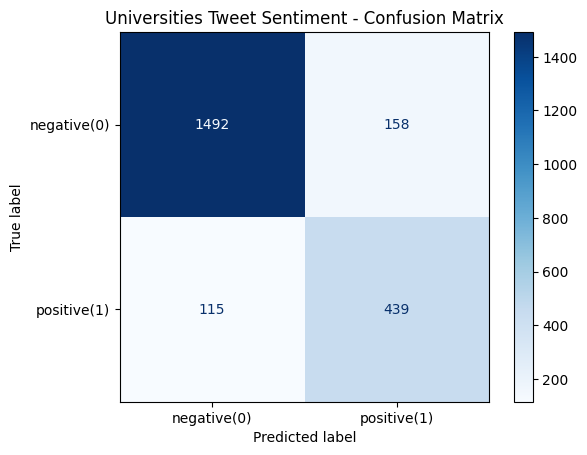

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_uni_pred = tweet_sentiment_clf.predict(X_uni_test)

print(f'Test Accuracy: {accuracy_score(y_uni_test, y_uni_pred):.4f}')
print('\nClassification Report:')
print(classification_report(
    y_uni_test, y_uni_pred,
    target_names=['negative(0)', 'positive(1)'],
    zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_uni_test, y_uni_pred,
    display_labels=['negative(0)', 'positive(1)'],
    cmap='Blues'
)
plt.title('Universities Tweet Sentiment - Confusion Matrix')
plt.show()


#### 7.5 Sonuçların Yorumu

- **Genel başarı:** Test doğruluğu **0.8761** (yaklaşık **%87.6**).  
  Model genel olarak iyi performans veriyor.

- **Sınıf bazında performans:**

  - **negative (0):** Precision **0.93**, Recall **0.90**, F1 **0.92** → çok güçlü.  
  - **positive (1):** Precision **0.74**, Recall **0.79**, F1 **0.76** → negatif sınıfa göre belirgin şekilde daha düşük.

- **Dengesizlik etkisi:** Support değerleri **1650 (negatif)** ve **554 (pozitif)**.  
  Veri negatif sınıfa daha yatkın olduğu için model negatifleri daha iyi öğrenmiş.

- **Macro vs weighted:**

  - **Macro F1 = 0.84** (sınıfları eşit ağırlıkla değerlendirir)  
  - **Weighted F1 = 0.88** (çoğunluk sınıfın etkisi yüksek)

  Aradaki fark, sınıf dengesizliğinin metriğe etkisini gösteriyor.

- **Yorum:** Model güçlü ama özellikle **pozitif sınıfın precision/F1 değeri** geliştirmeye açık.  
  Pozitif sınıf kritikse **class weight**, **threshold ayarı** veya **veri dengeleme yöntemleri** ile iyileştirme yapılabilir.

#### 7.6 Yeni Tweetlerden Tahmin Alma


In [ ]:
sample_tweets = [
    'Üniversitenin yeni kütüphanesi harika olmuş, çok beğendim.',
    'Yemekhane fiyatları aşırı artmış, bu durum çok kötü.',
    'Kampüsteki etkinlikler fena değil ama daha iyi olabilir.'
]

sample_clean = [clean_tweet(t) for t in sample_tweets]
sample_pred = tweet_sentiment_clf.predict(sample_clean)
sample_prob = tweet_sentiment_clf.predict_proba(sample_clean)[:, 1]  # positive probability

for tw, pred, p in zip(sample_tweets, sample_pred, sample_prob):
    sentiment = 'positive' if pred == 1 else 'negative'
    print(f'Tweet: {tw}')
    print(f'Prediction: {sentiment} | P(positive)={p:.3f}\n')


Tweet: Üniversitenin yeni kütüphanesi harika olmuş, çok beğendim.
Prediction: positive | P(positive)=0.923

Tweet: Yemekhane fiyatları aşırı artmış, bu durum çok kötü.
Prediction: negative | P(positive)=0.175

Tweet: Kampüsteki etkinlikler fena değil ama daha iyi olabilir.
Prediction: negative | P(positive)=0.485



### Bölüm 8 — Word2Vec ile Metin Temsili ve Model Eğitimi

Bu bölümde TF-IDF yerine Word2Vec kullanarak iki ayrı sınıflandırma örneği kuruluyor. Amaç, kelime gömme vektörleri ile belge temsili üretip aynı Logistic Regression yaklaşımıyla sonuçları karşılaştırmaktır.


#### 8.1 Film Türü Tahmini (Word2Vec + Logistic Regression)

In [ ]:
# import numpy as np
# from gensim.models import Word2Vec
# from sklearn.base import BaseEstimator, TransformerMixin

# def tokenize_for_w2v(text):
#     return re.findall(r"[^\W\d_]+", str(text).lower(), flags=re.UNICODE)


# class MeanWord2VecVectorizer(BaseEstimator, TransformerMixin):
#     def __init__(self, vector_size=100, window=5, min_count=3, workers=1, sg=1, epochs=15, seed=42):
#         self.vector_size = vector_size
#         self.window = window
#         self.min_count = min_count
#         self.workers = workers
#         self.sg = sg
#         self.epochs = epochs
#         self.seed = seed

#     def fit(self, X, y=None):
#         sentences = [tokenize_for_w2v(text) for text in X]
#         sentences = [tokens for tokens in sentences if tokens]
#         self.model_ = Word2Vec(
#             sentences=sentences,
#             vector_size=self.vector_size,
#             window=self.window,
#             min_count=self.min_count,
#             workers=self.workers,
#             sg=self.sg,
#             epochs=self.epochs,
#             seed=self.seed
#         )
#         return self

#     def transform(self, X):
#         return np.vstack([self._document_vector(tokenize_for_w2v(text)) for text in X])

#     def _document_vector(self, tokens):
#         vectors = [self.model_.wv[token] for token in tokens if token in self.model_.wv]
#         if vectors:
#             return np.mean(vectors, axis=0)
#         return np.zeros(self.model_.vector_size, dtype=float)


# genre_w2v_clf = Pipeline([
#     ('w2v', MeanWord2VecVectorizer(
#         vector_size=120,
#         window=5,
#         min_count=3,
#         epochs=20,
#         sg=1,
#         workers=1,
#         seed=42
#     )),
#     ('clf', LogisticRegression(
#         max_iter=1200,
#         class_weight='balanced',
#         n_jobs=-1
#     ))
# ])

# genre_w2v_clf.fit(X_train, y_train)
# y_pred_w2v = genre_w2v_clf.predict(X_test)

# print(f'Word2Vec Test Accuracy: {accuracy_score(y_test, y_pred_w2v):.4f}')
# print('\nWord2Vec Sınıflandırma Raporu (ilk 12 sınıf):')
# print(classification_report(y_test, y_pred_w2v, labels=labels_top, zero_division=0))

# ornek_aciklamalar_w2v = [
#     'A detective investigates a series of brutal murders in a dark and rainy city.',
#     'Two teenagers fall in love during a summer holiday by the sea.',
#     'A spaceship crew must survive after encountering an unknown alien life form.'
# ]

# print('\nÖrnek tahminler:')
# for metin, tur in zip(ornek_aciklamalar_w2v, genre_w2v_clf.predict(ornek_aciklamalar_w2v)):
#     print(f'- {tur}: {metin}')

In [ ]:
import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, f1_score


# -----------------------------
# 1) Prepare labels
# -----------------------------
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

num_labels = len(label_encoder.classes_)

# Keep these if you want readable label names later
id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in id2label.items()}


# -----------------------------
# 2) Build Hugging Face datasets
# -----------------------------
train_df = pd.DataFrame({
    "text": X_train.astype(str).tolist(),
    "label": y_train_enc
})

test_df = pd.DataFrame({
    "text": X_test.astype(str).tolist(),
    "label": y_test_enc
})

train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)


# -----------------------------
# 3) Tokenizer + tokenization
# -----------------------------
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_ds = train_ds.map(tokenize_batch, batched=True)
test_ds = test_ds.map(tokenize_batch, batched=True)

columns_to_keep = ["input_ids", "attention_mask", "label"]
train_ds.set_format(type="torch", columns=columns_to_keep)
test_ds.set_format(type="torch", columns=columns_to_keep)


# -----------------------------
# 4) Model
# -----------------------------
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)


# -----------------------------
# 5) Metrics
# -----------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted")
    }


# -----------------------------
# 6) Training arguments
# -----------------------------
training_args = TrainingArguments(
    output_dir="./distilbert_genre_cls",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    learning_rate=2e-5,
    save_total_limit=2,
    report_to="none",
    optim="adamw_torch"   # <- important fix
)


# -----------------------------
# 7) Trainer
# -----------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    # tokenizer=tokenizer,
    compute_metrics=compute_metrics
)


# -----------------------------
# 8) Train
# -----------------------------
trainer.train()


# -----------------------------
# 9) Evaluate on test
# -----------------------------
pred_output = trainer.predict(test_ds)
y_pred_ids = np.argmax(pred_output.predictions, axis=1)
y_pred_labels = label_encoder.inverse_transform(y_pred_ids)

print(f"DistilBERT Test Accuracy: {accuracy_score(y_test, y_pred_labels):.4f}")
print("\nDistilBERT Classification Report (first 12 classes):")
print(classification_report(y_test, y_pred_labels, labels=labels_top, zero_division=0))


# -----------------------------
# 10) Example predictions
# -----------------------------
ornek_aciklamalar_bert = [
    "A detective investigates a series of brutal murders in a dark and rainy city.",
    "Two teenagers fall in love during a summer holiday by the sea.",
    "A spaceship crew must survive after encountering an unknown alien life form."
]

example_ds = Dataset.from_dict({"text": ornek_aciklamalar_bert})
example_ds = example_ds.map(tokenize_batch, batched=True)
example_ds.set_format(type="torch", columns=["input_ids", "attention_mask"])

example_preds = trainer.predict(example_ds)
example_pred_ids = np.argmax(example_preds.predictions, axis=1)
example_pred_labels = label_encoder.inverse_transform(example_pred_ids)

print("\nÖrnek tahminler:")
for metin, tur in zip(ornek_aciklamalar_bert, example_pred_labels):
    print(f"- {tur}: {metin}")

Map:   0%|          | 0/125364 [00:00<?, ? examples/s]

Map:   0%|          | 0/31342 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.358370,1.227937,0.607492,0.335080,0.585090
2,1.087815,1.205496,0.621275,0.360469,0.598943
3,0.908435,1.251517,0.618340,0.374821,0.601555


...

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


DistilBERT Test Accuracy: 0.6183

DistilBERT Classification Report (first 12 classes):
                 precision    recall  f1-score   support

    Documentary       0.84      0.87      0.85      8184
          Drama       0.58      0.70      0.63      7888
         Comedy       0.54      0.49      0.51      3708
         Horror       0.55      0.69      0.61      2646
      Animation       0.51      0.49      0.50      2225
       Thriller       0.33      0.19      0.24      1170
          Music       0.76      0.65      0.70       955
         Action       0.45      0.43      0.44       878
        Romance       0.36      0.20      0.26       802
Science Fiction       0.41      0.39      0.40       569
          Crime       0.32      0.24      0.28       515
        Fantasy       0.27      0.08      0.13       391

      micro avg       0.62      0.64      0.63     29931
      macro avg       0.49      0.45      0.46     29931
   weighted avg       0.61      0.64      0.62     29931

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Örnek tahminler:
- Crime: A detective investigates a series of brutal murders in a dark and rainy city.
- Romance: Two teenagers fall in love during a summer holiday by the sea.
- Science Fiction: A spaceship crew must survive after encountering an unknown alien life form.


#### 8.2 Tweet Duygu Analizi (Word2Vec + Logistic Regression)

In [ ]:
tweet_sentiment_w2v_clf = Pipeline([
    ('w2v', MeanWord2VecVectorizer(
        vector_size=100,
        window=4,
        min_count=2,
        epochs=20,
        sg=1,
        workers=1,
        seed=42
    )),
    ('clf', LogisticRegression(
        max_iter=1200,
        class_weight='balanced',
        n_jobs=-1
    ))
])

tweet_sentiment_w2v_clf.fit(X_uni_train, y_uni_train)
y_uni_pred_w2v = tweet_sentiment_w2v_clf.predict(X_uni_test)

print(f'Word2Vec Test Accuracy: {accuracy_score(y_uni_test, y_uni_pred_w2v):.4f}')
print('\nWord2Vec Classification Report:')
print(classification_report(
    y_uni_test, y_uni_pred_w2v,
    target_names=['negative(0)', 'positive(1)'],
    zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_uni_test, y_uni_pred_w2v,
    display_labels=['negative(0)', 'positive(1)'],
    cmap='Greens'
)
plt.title('Universities Tweet Sentiment - Word2Vec Confusion Matrix')
plt.show()